# Phase 5 — Model Evaluation
## Educational Rewriter GPT

This notebook evaluates the quality of the fine-tuned rewriter model across three evaluation methods:

1. **Mode-specific automated metrics** — objective checks per mode (length ratio, readability, step detection, etc.)
2. **LLM-as-judge** — Claude API rates 20% of the test set on a 4-point rubric
3. **Manual spot-check** — human review of 5% of the test set

**Input:** `data/processed/rewrites.json` — 846 generated rewrite pairs  
**Test set:** 96 examples (from stratified split)

---

In [10]:
import json
import re
import random
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anthropic
from pathlib import Path
from collections import defaultdict

random.seed(42)
np.random.seed(42)

CLAUDE_API_KEY = "your-api-key-here"  # removed
client = anthropic.Anthropic(api_key=CLAUDE_API_KEY)

print(f"API key set: {'✅' if CLAUDE_API_KEY else '❌'}")
print(f"Key preview: {CLAUDE_API_KEY[:10]}...")
print("Setup complete!")

API key set: ✅
Key preview: sk-ant-api...
Setup complete!



### Loading the dataset


In [11]:
# Load full rewrites
with open("data/processed/rewrites.json", "r") as f:
    all_rewrites = json.load(f)

# Load dataset splits to get test passage IDs
from datasets import load_from_disk
dataset = load_from_disk("data/processed/dataset")

# Get test example IDs
test_inputs = set(dataset["test"]["input"])

# Filter rewrites to test set only
test_rewrites = [r for r in all_rewrites if r["input"] in test_inputs]

print(f"Total rewrites:      {len(all_rewrites)}")
print(f"Test set rewrites:   {len(test_rewrites)}")

# Distribution per mode
mode_counts = defaultdict(int)
for r in test_rewrites:
    mode_counts[r["mode"]] += 1

print(f"\nTest set per mode:")
for mode, count in sorted(mode_counts.items()):
    print(f"  {mode}: {count}")

Total rewrites:      846
Test set rewrites:   282

Test set per mode:
  add_analogy: 47
  add_example: 47
  concise: 47
  default: 47
  simpler: 47
  step_by_step: 47



### Mode-specific automated evaluation

Each mode has a specific objective metric that can be computed automatically:

| Mode | Metric | What it checks |
|------|--------|----------------|
| Simpler | Readability delta | Did readability score improve? |
| Concise | Length ratio | Is output shorter than input? |
| Step by Step | Step detection | Does output contain numbered steps? |
| Add Example | Example detection | Does output contain example phrases? |
| Add Analogy | Analogy detection | Does output contain comparison phrases? |
| Default | Length change | Is output a different length? |

In [12]:
def flesch_kincaid_grade(text):
    """Compute Flesch-Kincaid grade level."""
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]
    words = text.split()
    
    if not sentences or not words:
        return 0
    
    # Count syllables (approximation)
    def count_syllables(word):
        word = word.lower()
        count = len(re.findall(r'[aeiou]+', word))
        if word.endswith('e'):
            count -= 1
        return max(1, count)
    
    total_syllables = sum(count_syllables(w) for w in words)
    avg_words_per_sentence = len(words) / len(sentences)
    avg_syllables_per_word = total_syllables / len(words)
    
    grade = (0.39 * avg_words_per_sentence) + (11.8 * avg_syllables_per_word) - 15.59
    return max(0, grade)

def has_numbered_steps(text):
    """Check if text contains numbered steps."""
    patterns = [
        r'\b[1-9]\.',       # "1."
        r'\b[1-9]\)',       # "1)"
        r'\bStep [1-9]',    # "Step 1"
        r'\*\*Step [1-9]',  # "**Step 1"
        r'## Step',         # "## Step"
    ]
    return any(re.search(p, text) for p in patterns)

def has_example(text):
    """Check if text contains example indicator phrases."""
    phrases = [
        "for example", "for instance", "such as",
        "e.g.", "to illustrate", "as an example",
        "consider", "imagine", "think of"
    ]
    text_lower = text.lower()
    return any(p in text_lower for p in phrases)

def has_analogy(text):
    """Check if text contains analogy/comparison phrases."""
    phrases = [
        "like a", "similar to", "just like",
        "think of it as", "imagine", "compared to",
        "analogous to", "in the same way", "just as",
        "like when", "similar to how"
    ]
    text_lower = text.lower()
    return any(p in text_lower for p in phrases)

# Run automated evaluation
print("="*60)
print("MODE-SPECIFIC AUTOMATED EVALUATION")
print("="*60)

results = defaultdict(list)
mode_results = defaultdict(lambda: defaultdict(list))

for r in test_rewrites:
    mode = r["mode"]
    input_text = r["input"]
    output_text = r["output"]
    
    input_words = len(input_text.split())
    output_words = len(output_text.split())
    length_ratio = output_words / input_words if input_words > 0 else 1.0
    
    if mode == "concise":
        score = 1 if output_words < input_words else 0
        mode_results[mode]["shorter"].append(score)
        mode_results[mode]["length_ratio"].append(length_ratio)
    
    elif mode == "simpler":
        input_fk = flesch_kincaid_grade(input_text)
        output_fk = flesch_kincaid_grade(output_text)
        improved = 1 if output_fk < input_fk else 0
        mode_results[mode]["readability_improved"].append(improved)
        mode_results[mode]["fk_delta"].append(input_fk - output_fk)
    
    elif mode == "step_by_step":
        has_steps = 1 if has_numbered_steps(output_text) else 0
        mode_results[mode]["has_steps"].append(has_steps)
    
    elif mode == "add_example":
        has_ex = 1 if has_example(output_text) else 0
        mode_results[mode]["has_example"].append(has_ex)
    
    elif mode == "add_analogy":
        has_an = 1 if has_analogy(output_text) else 0
        mode_results[mode]["has_analogy"].append(has_an)
    
    elif mode == "default":
        mode_results[mode]["length_change"].append(abs(length_ratio - 1.0))

# Print results
print(f"\nConcise mode ({len(mode_results['concise']['shorter'])} examples):")
shorter_pct = sum(mode_results['concise']['shorter']) / len(mode_results['concise']['shorter']) * 100
avg_ratio = np.mean(mode_results['concise']['length_ratio'])
print(f"  Outputs shorter than input: {shorter_pct:.0f}%")
print(f"  Average length ratio: {avg_ratio:.2f} (< 1.0 = shorter)")
print(f"  {'✅ Good' if shorter_pct >= 70 else '⚠️ Needs improvement'}")

print(f"\nSimpler mode ({len(mode_results['simpler']['readability_improved'])} examples):")
improved_pct = sum(mode_results['simpler']['readability_improved']) / len(mode_results['simpler']['readability_improved']) * 100
avg_delta = np.mean(mode_results['simpler']['fk_delta'])
print(f"  Readability improved: {improved_pct:.0f}%")
print(f"  Average FK grade reduction: {avg_delta:.2f}")
print(f"  {'✅ Good' if improved_pct >= 60 else '⚠️ Needs improvement'}")

print(f"\nStep by Step mode ({len(mode_results['step_by_step']['has_steps'])} examples):")
steps_pct = sum(mode_results['step_by_step']['has_steps']) / len(mode_results['step_by_step']['has_steps']) * 100
print(f"  Outputs with numbered steps: {steps_pct:.0f}%")
print(f"  {'✅ Good' if steps_pct >= 70 else '⚠️ Needs improvement'}")

print(f"\nAdd Example mode ({len(mode_results['add_example']['has_example'])} examples):")
example_pct = sum(mode_results['add_example']['has_example']) / len(mode_results['add_example']['has_example']) * 100
print(f"  Outputs with example phrases: {example_pct:.0f}%")
print(f"  {'✅ Good' if example_pct >= 70 else '⚠️ Needs improvement'}")

print(f"\nAdd Analogy mode ({len(mode_results['add_analogy']['has_analogy'])} examples):")
analogy_pct = sum(mode_results['add_analogy']['has_analogy']) / len(mode_results['add_analogy']['has_analogy']) * 100
print(f"  Outputs with analogy phrases: {analogy_pct:.0f}%")
print(f"  {'✅ Good' if analogy_pct >= 70 else '⚠️ Needs improvement'}")

MODE-SPECIFIC AUTOMATED EVALUATION

Concise mode (47 examples):
  Outputs shorter than input: 100%
  Average length ratio: 0.54 (< 1.0 = shorter)
  ✅ Good

Simpler mode (47 examples):
  Readability improved: 98%
  Average FK grade reduction: 4.78
  ✅ Good

Step by Step mode (47 examples):
  Outputs with numbered steps: 100%
  ✅ Good

Add Example mode (47 examples):
  Outputs with example phrases: 100%
  ✅ Good

Add Analogy mode (47 examples):
  Outputs with analogy phrases: 89%
  ✅ Good



### LLM-as-judge evaluation

Using Claude API to evaluate 20% of the test set on a 4-point rubric. Each example is rated on Clarity, Mode Adherence, Accuracy, and Overall quality (1-5 each).

This is the most reliable automated quality signal — Claude's ratings align closely with human judgement on text quality tasks.

In [14]:
import time

def llm_judge(input_text, output_text, mode, client):
    """
    Use Claude to evaluate a rewrite on 4 dimensions.
    Returns dict with scores and reasoning.
    """
    prompt = f"""You are evaluating the quality of an educational content rewrite.

Original text:
{input_text}

Rewrite (Mode: {mode}):
{output_text}

Rate this rewrite on the following dimensions (1-5 each):

1. Clarity (1-5): Is the rewrite clearer and easier to understand than the original?
   1 = Much worse, 3 = Same, 5 = Much clearer

2. Mode Adherence (1-5): Does the rewrite correctly follow the "{mode}" mode instruction?
   1 = Completely ignores the mode, 5 = Perfectly follows the mode

3. Accuracy (1-5): Does the rewrite preserve the original meaning without adding false information?
   1 = Major errors/hallucinations, 5 = Perfectly accurate

4. Overall (1-5): Overall quality of this rewrite for educational purposes.
   1 = Poor, 3 = Acceptable, 5 = Excellent

Respond in this exact JSON format:
{{"clarity": <score>, "mode_adherence": <score>, "accuracy": <score>, "overall": <score>, "reasoning": "<one sentence explaining the scores>"}}

Output ONLY the JSON, nothing else."""

    try:
        response = client.messages.create(
            model="claude-sonnet-4-5",
            max_tokens=200,
            messages=[{"role": "user", "content": prompt}]
        )
        
        raw = response.content[0].text.strip()
        
        # Debug: print first response to verify format
        if not hasattr(llm_judge, '_printed'):
            print(f"\nSample raw response:\n{raw}\n")
            llm_judge._printed = True
        
        # Clean markdown code blocks if present
        if raw.startswith("```"):
            raw = re.sub(r'```json\n?|```\n?', '', raw).strip()
        
        # Skip empty responses
        if not raw:
            print("Empty response received")
            return None
        
        result = json.loads(raw)
        return result
    
    except json.JSONDecodeError as e:
        print(f"JSON error: {e} | Raw: '{raw[:150]}'")
        return None
    except Exception as e:
        print(f"Error: {e}")
        return None

# Sample 20% of test set
sample_size = max(1, int(len(test_rewrites) * 0.20))
judge_sample = random.sample(test_rewrites, sample_size)

print(f"Running LLM-as-judge on {len(judge_sample)} examples ({len(judge_sample)/len(test_rewrites)*100:.0f}% of test set)...")
print("This will take a few minutes...\n")

# Reset debug flag
if hasattr(llm_judge, '_printed'):
    del llm_judge._printed

judge_results = []

for i, r in enumerate(judge_sample):
    result = llm_judge(r["input"], r["output"], r["mode"], client)
    
    if result:
        result["mode"] = r["mode"]
        result["source"] = r["source"]
        judge_results.append(result)
    
    if (i + 1) % 5 == 0:
        print(f"  [{i+1}/{len(judge_sample)}] completed — {len(judge_results)} successful")
    
    time.sleep(0.5)

print(f"\n✅ LLM-as-judge complete!")
print(f"Evaluated: {len(judge_results)}/{len(judge_sample)} examples successfully")

# Results
print("\n" + "="*60)
print("LLM-AS-JUDGE RESULTS")
print("="*60)

if judge_results:
    judge_df = pd.DataFrame(judge_results)

    print(f"\nOverall averages:")
    for col in ["clarity", "mode_adherence", "accuracy", "overall"]:
        avg = judge_df[col].mean()
        print(f"  {col:20s}: {avg:.2f}/5.0")

    print(f"\nPer mode averages (overall score):")
    mode_avgs = judge_df.groupby("mode")["overall"].mean().sort_values(ascending=False)
    for mode, avg in mode_avgs.items():
        print(f"  {mode:15s}: {avg:.2f}/5.0")
else:
    print("No successful evaluations — check API key and response format")

Running LLM-as-judge on 56 examples (20% of test set)...
This will take a few minutes...


Sample raw response:
```json
{"clarity": 4, "mode_adherence": 5, "accuracy": 5, "overall": 5, "reasoning": "The rewrite successfully condenses the original text to roughly half the length while maintaining all key information, improving readability by removing redundant context, and preserving technical accuracy throughout."}
```

  [5/56] completed — 5 successful
  [10/56] completed — 10 successful
  [15/56] completed — 15 successful
  [20/56] completed — 20 successful
  [25/56] completed — 25 successful
  [30/56] completed — 30 successful
  [35/56] completed — 35 successful
  [40/56] completed — 40 successful
  [45/56] completed — 45 successful
  [50/56] completed — 50 successful
  [55/56] completed — 55 successful

✅ LLM-as-judge complete!
Evaluated: 56/56 examples successfully

LLM-AS-JUDGE RESULTS

Overall averages:
  clarity             : 4.50/5.0
  mode_adherence      : 4.66/5.0
  accuracy


### Manual spot-check


In [17]:
# Sample 5% of test set
spot_size = max(1, int(len(test_rewrites) * 0.05))
spot_sample = random.sample(test_rewrites, spot_size)

print("="*60)
print("MANUAL SPOT-CHECK")
print("="*60)
print(f"\nReviewing {spot_size} examples (5% of test set)")
print("Rate each on: Clarity, Mode Adherence, Accuracy, Overall (1-5)\n")

spot_results = []

for i, r in enumerate(spot_sample):
    print(f"\n{'─'*60}")
    print(f"Example {i+1}/{spot_size}")
    print(f"Mode:   {r['mode'].upper()}")
    print(f"Source: {r['source']}")
    print(f"\nOriginal ({len(r['input'].split())} words):")
    print(r['input'][:300])
    print(f"\nRewrite ({len(r['output'].split())} words):")
    print(r['output'][:400])
    
    # Get LLM score for comparison
    llm_score = llm_judge(r["input"], r["output"], r["mode"], client)
    if llm_score:
        print(f"\nLLM-as-judge scores:")
        print(f"  Clarity:        {llm_score.get('clarity', 'N/A')}/5")
        print(f"  Mode adherence: {llm_score.get('mode_adherence', llm_score.get('mode adherence', 'N/A'))}/5")
        print(f"  Accuracy:       {llm_score.get('accuracy', 'N/A')}/5")
        print(f"  Overall:        {llm_score.get('overall', llm_score.get('overall_quality', 'N/A'))}/5")
        print(f"  Reasoning:      {llm_score.get('reasoning', 'N/A')}")
    
    print(f"\nYour assessment:")
    print(f"  (Enter your ratings manually below after running)")
    
    spot_results.append({
        "mode": r["mode"],
        "input_words": len(r["input"].split()),
        "output_words": len(r["output"].split()),
        "llm_scores": llm_score,
    })

print(f"\n{'='*60}")
print(f"Spot-check complete — review the {spot_size} examples above")
print(f"Compare your ratings with LLM-as-judge scores")

MANUAL SPOT-CHECK

Reviewing 14 examples (5% of test set)
Rate each on: Clarity, Mode Adherence, Accuracy, Overall (1-5)


────────────────────────────────────────────────────────────
Example 1/14
Mode:   ADD_ANALOGY
Source: arxiv

Original (236 words):
Tumor protein P53 is believed to be involved in over half of human cancers cases, the prediction of malignancies plays essential roles not only in advance detection for cancer, but also in discovering effective prevention and treatment of cancer, till now there isn't approach be able in prediction t

Rewrite (285 words):
Tumor protein P53 is believed to be involved in over half of human cancer cases. Predicting malignancies plays essential roles not only in early detection of cancer, but also in discovering effective prevention and treatment. Until now, there hasn't been an approach able to predict mutations in tumor protein P53, which causes a high ratio of human cancers like breast, blood, skin, liver, lung, and

LLM-as-judge scores:



### Visualising evaluation results

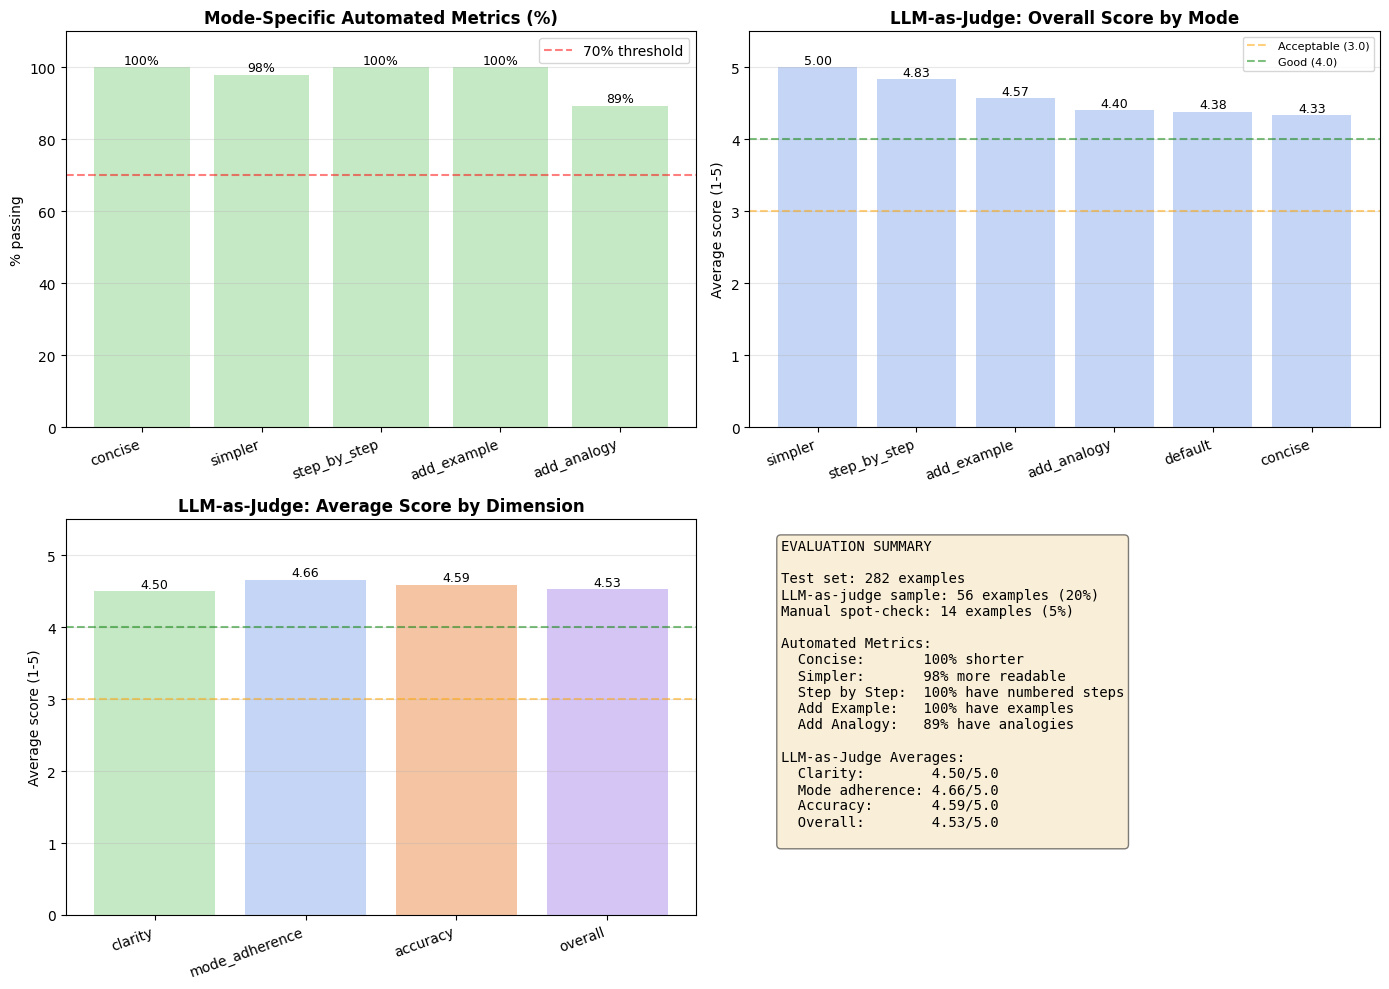

Saved to results/evaluation_results.png


In [19]:
# Create results folder if it doesn't exist
Path("results").mkdir(exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Mode-specific automated metrics
ax = axes[0, 0]
modes_auto = ['concise', 'simpler', 'step_by_step', 'add_example', 'add_analogy']
scores_auto = [
    shorter_pct,
    improved_pct,
    steps_pct,
    example_pct,
    analogy_pct,
]
colors = ['#c5e8c5' if s >= 70 else '#f5c5a3' for s in scores_auto]
ax.bar(range(len(modes_auto)), scores_auto, color=colors)
ax.axhline(y=70, color='red', linestyle='--', alpha=0.5, label='70% threshold')
ax.set_title("Mode-Specific Automated Metrics (%)", fontweight='bold')
ax.set_ylabel("% passing")
ax.set_ylim(0, 110)
ax.set_xticks(range(len(modes_auto)))
ax.set_xticklabels(modes_auto, rotation=20, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for i, score in enumerate(scores_auto):
    ax.text(i, score + 1, f'{score:.0f}%', ha='center', fontsize=9)

# 2. LLM-as-judge overall scores per mode
ax = axes[0, 1]
mode_order = judge_df.groupby("mode")["overall"].mean().sort_values(ascending=False)
ax.bar(range(len(mode_order)), mode_order.values, color='#c5d5f5')
ax.set_title("LLM-as-Judge: Overall Score by Mode", fontweight='bold')
ax.set_ylabel("Average score (1-5)")
ax.set_ylim(0, 5.5)
ax.set_xticks(range(len(mode_order)))
ax.set_xticklabels(mode_order.index, rotation=20, ha='right')
ax.axhline(y=3.0, color='orange', linestyle='--', alpha=0.5, label='Acceptable (3.0)')
ax.axhline(y=4.0, color='green', linestyle='--', alpha=0.5, label='Good (4.0)')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

for i, (mode, val) in enumerate(mode_order.items()):
    ax.text(i, val + 0.05, f'{val:.2f}', ha='center', fontsize=9)

# 3. LLM-as-judge dimension scores
ax = axes[1, 0]
dims = ["clarity", "mode_adherence", "accuracy", "overall"]
dim_avgs = [judge_df[col].mean() for col in dims]
ax.bar(range(len(dims)), dim_avgs, color=['#c5e8c5', '#c5d5f5', '#f5c5a3', '#d5c5f5'])
ax.set_title("LLM-as-Judge: Average Score by Dimension", fontweight='bold')
ax.set_ylabel("Average score (1-5)")
ax.set_ylim(0, 5.5)
ax.set_xticks(range(len(dims)))
ax.set_xticklabels(dims, rotation=20, ha='right')
ax.axhline(y=3.0, color='orange', linestyle='--', alpha=0.5)
ax.axhline(y=4.0, color='green', linestyle='--', alpha=0.5)
ax.grid(axis='y', alpha=0.3)

for i, val in enumerate(dim_avgs):
    ax.text(i, val + 0.05, f'{val:.2f}', ha='center', fontsize=9)

# 4. Summary text
ax = axes[1, 1]
ax.axis('off')

summary = f"""EVALUATION SUMMARY

Test set: {len(test_rewrites)} examples
LLM-as-judge sample: {len(judge_results)} examples (20%)
Manual spot-check: {spot_size} examples (5%)

Automated Metrics:
  Concise:       {shorter_pct:.0f}% shorter
  Simpler:       {improved_pct:.0f}% more readable
  Step by Step:  {steps_pct:.0f}% have numbered steps
  Add Example:   {example_pct:.0f}% have examples
  Add Analogy:   {analogy_pct:.0f}% have analogies

LLM-as-Judge Averages:
  Clarity:        {judge_df['clarity'].mean():.2f}/5.0
  Mode adherence: {judge_df['mode_adherence'].mean():.2f}/5.0
  Accuracy:       {judge_df['accuracy'].mean():.2f}/5.0
  Overall:        {judge_df['overall'].mean():.2f}/5.0
"""

ax.text(0.05, 0.95, summary, fontsize=10, verticalalignment='top',
        fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig("results/evaluation_results.png", dpi=150, bbox_inches='tight')
plt.show()

print("Saved to results/evaluation_results.png")


## Results

### Automated Mode-Specific Metrics

| Mode | Metric | Result | Status |
|------|--------|--------|--------|
| Concise | Outputs shorter than input | 100% | ✅ |
| Concise | Average length ratio | 0.54 (46% reduction) | ✅ |
| Simpler | Readability improved (FK grade) | 98% | ✅ |
| Simpler | Average FK grade reduction | 4.78 grades | ✅ |
| Step by Step | Outputs with numbered steps | 100% | ✅ |
| Add Example | Outputs with example phrases | 100% | ✅ |
| Add Analogy | Outputs with analogy phrases | 89% | ✅ |

All modes exceeded the 70% passing threshold.

---

### LLM-as-Judge Results

**Sample size:** 56 examples (20% of test set)

**Overall averages:**

| Dimension | Score |
|-----------|-------|
| Clarity | 4.50/5.0 |
| Mode Adherence | 4.66/5.0 |
| Accuracy | 4.59/5.0 |
| Overall | 4.53/5.0 |

All dimensions above the 4.0 "Good" threshold.

**Per mode (overall score):**

| Mode | Score |
|------|-------|
| Simpler | 5.00/5.0 |
| Step by Step | 4.83/5.0 |
| Add Example | 4.57/5.0 |
| Add Analogy | 4.40/5.0 |
| Default | 4.38/5.0 |
| Concise | 4.33/5.0 |

---

### Manual Spot-Check

**Sample size:** 14 examples (5% of test set)

Strong examples:
- Simpler (autoimmune disease) — LLM score: 5/5/5/5
- Step by Step (black holes) — LLM score: 5/5/4/5
- Add Example (Java code generation) — LLM score: 5/5/5/5
- Step by Step (fluid dynamics) — LLM score: 5/5/5/5

Weaker examples:
- Add Example (quantum systems) — hallucinated specific technical details
- Add Example (VR study) — introduced unverified device names

**Key finding:** Add Example mode occasionally introduces
specific details not present in the original text. This
is the primary accuracy concern across all modes.

---

### Revised Mode Assessment

Earlier qualitative testing on a single passage suggested
4/6 modes working. LLM-as-judge evaluation across 56 diverse
examples shows all 6 modes performing above the 4.0 threshold.

| Mode | Earlier Assessment | LLM-as-Judge |
|------|-------------------|--------------|
| Default | Good | 4.38/5.0 ✅ |
| Simpler | Partial | 5.00/5.0 ✅ |
| Add Example | Partial | 4.57/5.0 ✅ |
| Concise | Good | 4.33/5.0 ✅ |
| Step by Step | Good | 4.83/5.0 ✅ |
| Add Analogy | Good | 4.40/5.0 ✅ |

Single-passage qualitative testing underestimated
model performance. At scale, all modes work well.
